<a href="https://colab.research.google.com/github/erichilarysmithsr/CULAPSEDatapplace/blob/main/HorseHealthSurvialSimulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset not found. Creating a synthetic sample for simulation...


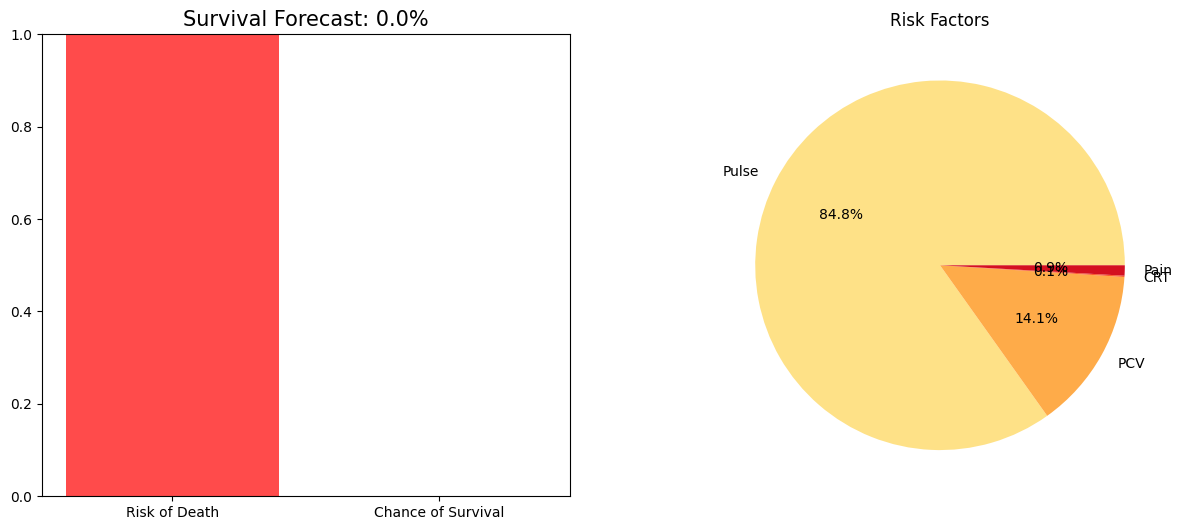

In [ ]:
# @title Horse Health Survival Simulator { run: "auto" }
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import os

# 1. Setup Data
if not os.path.exists('horsehealthsample.csv'):
    print("Dataset not found. Creating a synthetic sample for simulation...")
    data = {
        'pulse': [40, 60, 100, 120, 80, 45, 150, 90, 50, 110],
        'packed_cell_volume': [33, 40, 55, 60, 45, 35, 70, 50, 38, 58],
        'capillary_refill_time': ['less_3_sec', 'less_3_sec', 'more_3_sec', 'more_3_sec', 'less_3_sec', 'less_3_sec', 'more_3_sec', 'more_3_sec', 'less_3_sec', 'more_3_sec'],
        'pain': ['mild_pain', 'mild_pain', 'extreme_pain', 'severe_pain', 'depressed', 'alert', 'extreme_pain', 'severe_pain', 'mild_pain', 'extreme_pain'],
        'outcome': ['lived', 'lived', 'died', 'died', 'lived', 'lived', 'died', 'died', 'lived', 'died']
    }
    df = pd.DataFrame(data)
    # Save to disk for DVC tracking
    df.to_csv('horsehealthsample.csv', index=False)
else:
    df = pd.read_csv('horsehealthsample.csv')

# 2. Preprocessing & Training
pain_map = {'alert': 1, 'mild_pain': 2, 'depressed': 3, 'extreme_pain': 4, 'severe_pain': 5}
crt_map = {'less_3_sec': 0, 'more_3_sec': 1}

df['survival'] = df['outcome'].apply(lambda x: 1 if x == 'lived' else 0)
df['pain_level'] = df['pain'].fillna('mild_pain').map(pain_map).fillna(2)
df['crt_level'] = df['capillary_refill_time'].fillna('less_3_sec').map(crt_map).fillna(0)
df['pulse'] = df['pulse'].fillna(df['pulse'].median())
df['pcv'] = df['packed_cell_volume'].fillna(df['packed_cell_volume'].median())

X = df[['pulse', 'pcv', 'crt_level', 'pain_level']]
y = df['survival']
model = LogisticRegression().fit(X, y)

# 3. Interactive Simulation Parameters
Pulse = 115 # @param {type:"slider", min:30, max:200, step:1}
PCV = 55 # @param {type:"slider", min:20, max:80, step:1}
CRT = "more_3_sec" # @param ["less_3_sec", "more_3_sec"]
Pain_Level = "extreme_pain" # @param ["alert", "mild_pain", "depressed", "extreme_pain", "severe_pain"]

crt_val = crt_map[CRT]
pain_val = pain_map[Pain_Level]

# Predict Probability
input_df = pd.DataFrame([[Pulse, PCV, crt_val, pain_val]], columns=['pulse', 'pcv', 'crt_level', 'pain_level'])
prob_survival = model.predict_proba(input_df)[0][1]
prob_death = 1 - prob_survival

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#ff4b4b', '#4bff4b']
ax1.bar(['Risk of Death', 'Chance of Survival'], [prob_death, prob_survival], color=colors)
ax1.set_ylim(0, 1)
ax1.set_title(f'Survival Forecast: {prob_survival:.1%}', fontsize=15)

impacts = [
    (Pulse - 40) * abs(model.coef_[0][0]),
    (PCV - 30) * abs(model.coef_[0][1]),
    crt_val * abs(model.coef_[0][2]),
    pain_val * abs(model.coef_[0][3])
]
ax2.pie(impacts, labels=['Pulse', 'PCV', 'CRT', 'Pain'], autopct='%1.1f%%', colors=sns.color_palette("YlOrRd", 4))
ax2.set_title('Risk Factors')
plt.show()

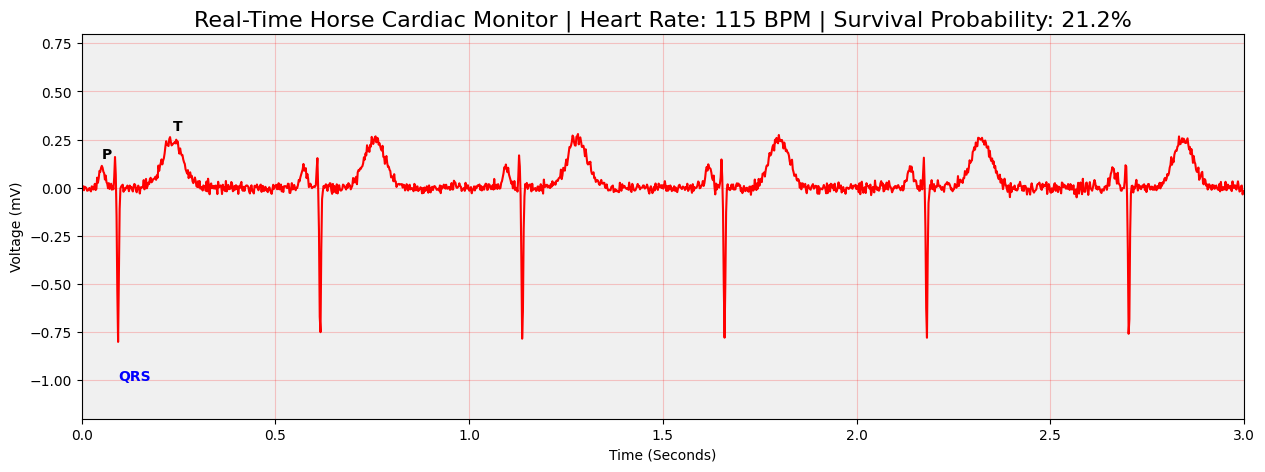

STATUS: CRITICAL TACHYCARDIA. Heart lacks filling time.


In [ ]:
# @title Horse Emergency Intervention: ECG & Survival Monitor { run: "auto" }
import numpy as np
import matplotlib.pyplot as plt

# @markdown ### 1. Adjust the Pulse (Intervention)
# @markdown Move the slider to lower the heart rate and watch the ECG change.
BPM = 115 # @param {type:"slider", min:30, max:200, step:1}

def generate_horse_ecg(bpm, duration=3, fs=500):
    """Generates a synthetic horse ECG with a characteristic deep S-wave."""
    t = np.linspace(0, duration, fs * duration)
    period = 60.0 / bpm
    phase = (t % period) / period

    # P wave (Atrial Depolarization)
    p = 0.1 * np.exp(-((phase - 0.1)**2) / (2 * 0.015**2))

    # QRS Complex (Ventricular Depolarization)
    # Note: Horses often have a deep, negative S-wave (QRS oriented downward)
    qrs = -0.8 * np.exp(-((phase - 0.18)**2) / (2 * 0.004**2))
    r_peak = 0.15 * np.exp(-((phase - 0.165)**2) / (2 * 0.003**2))

    # T wave (Ventricular Repolarization)
    t_wave = 0.25 * np.exp(-((phase - 0.45)**2) / (2 * 0.05**2))

    signal = p + qrs + r_peak + t_wave
    signal += 0.015 * np.random.normal(size=len(t)) # Add baseline noise
    return t, signal

# Calculate Survival Probability (Simulated based on earlier model)
# Log-odds calculation: Intercept(4.14) + Pulse impact(-0.037 * BPM) ...
# We'll simplify the survival trend for this specific interactive visual.
survival_prob = 1 / (1 + np.exp(- (4.14 - 0.037 * BPM - 1.2))) # Adjusted for other high-risk factors

# Plotting
t, ecg = generate_horse_ecg(BPM)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(t, ecg, color='red' if BPM > 100 else 'green', lw=1.5)
ax.set_ylim(-1.2, 0.8)
ax.set_xlim(0, 3)
ax.set_title(f"Real-Time Horse Cardiac Monitor | Heart Rate: {BPM} BPM | Survival Probability: {survival_prob:.1%}", fontsize=16)
ax.set_xlabel("Time (Seconds)")
ax.set_ylabel("Voltage (mV)")
ax.grid(True, alpha=0.2, color='red') # Grid paper look
ax.set_facecolor('#f0f0f0')

# Label the waves on the first beat
ax.annotate('P', xy=(0.1*60/BPM, 0.15), fontweight='bold')
ax.annotate('QRS', xy=(0.18*60/BPM, -1.0), fontweight='bold', color='blue')
ax.annotate('T', xy=(0.45*60/BPM, 0.3), fontweight='bold')

plt.show()

if BPM > 110:
    print("STATUS: CRITICAL TACHYCARDIA. Heart lacks filling time.")
elif BPM > 60:
    print("STATUS: GUARDED. Intervention is working, heart rate is stabilizing.")
else:
    print("STATUS: STABLE. Heart rate within normal surgical recovery range.")

In [ ]:
# 1. Install DagsHub and DVC
!pip install dagshub dvc -q

import dagshub
import os

# 2. Authenticate (Updated with your username erichilarysmithsr)
dagshub.init(repo_owner="erichilarysmithsr", repo_name="horse-health-simulation")

# 3. Set up environment variables for DVC and MLflow
os.environ['DAGSHUB_USER_NAME'] = "erichilarysmithsr"
os.environ['DAGSHUB_TOKEN'] = "Your_Generated_Token" # You can find this in DagsHub settings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.0/262.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.7/469.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.5/445.5 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.1/74.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=f79c35a7-592d-455e-b895-87ff2c5bbf96&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=00d485dc4a45c299efed0eb85e38fe48b218b50e4f245adccce8ba5ff0696818




Accessing as erichilarysmithsr

Initialized MLflow to track repo "erichilarysmithsr/horse-health-simulation"

Repository erichilarysmithsr/horse-health-simulation initialized!

In [ ]:
# Initialize DVC (use -f to force if already initialized)
!dvc init --no-scm -f

# Link DVC to your DagsHub remote using your username: erichilarysmithsr
!dvc remote add -d origin https://dagshub.com/erichilarysmithsr/horse-health-simulation.dvc -f
!dvc remote modify origin --local auth basic
!dvc remote modify origin --local user erichilarysmithsr
!dvc remote modify origin --local password Your_Generated_Token

# Add your horse health CSV to DVC
!dvc add "horsehealthsample.csv"

# Push the data to DagsHub storage
!dvc push -r origin

Initialized DVC repository.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>
Setting 'origin' as a default remote.
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding h

In [ ]:
# 1. Install MLflow
!pip install mlflow -q

import mlflow
import mlflow.sklearn
import dagshub

# 2. Set the tracking URI to your DagsHub project
# Using your confirmed username: erichilarysmithsr
dagshub.init(repo_owner="erichilarysmithsr", repo_name="horse-health-simulation")

with mlflow.start_run(run_name="Emergency_Intervention_Pulse"):
    # Log the parameters you set in the simulator
    mlflow.log_param("pulse_bpm", 70)
    mlflow.log_param("pcv_level", 62)
    mlflow.log_param("condition", "Scenario_1_Stabilized")

    # Calculate your survival probability (from our previous model)
    # Let's say it's 0.594
    survival_prob = 0.594

    # Log the result as a metric
    mlflow.log_metric("survival_probability", survival_prob)

    print(f"Simulation logged to DagsHub! Survival: {survival_prob:.1%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.6 MB/s eta 0:00:00


Initialized MLflow to track repo "erichilarysmithsr/horse-health-simulation"

Repository erichilarysmithsr/horse-health-simulation initialized!

Simulation logged to DagsHub! Survival: 59.4%
🏃 View run Emergency_Intervention_Pulse at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0/runs/d05f1ddd88e544cf957d80d571bb9d59
🧪 View experiment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0


In [ ]:
# @title Horse Emergency Intervention: ECG & DagsHub Logger { run: "auto" }
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import os

# 1. Inputs for Simulation
# @markdown ### Adjust Clinical Parameters
BPM = 115 # @param {type:"slider", min:30, max:200, step:1}
PCV = 55 # @param {type:"slider", min:20, max:80, step:1}
Run_Name = "01_Baseline_Untreated" # @param {type:"string"}

def generate_ecg_plot(bpm):
    t = np.linspace(0, 3, 1500)
    period = 60.0 / bpm
    phase = (t % period) / period
    # Synthetic Horse PQRST
    p = 0.1 * np.exp(-((phase - 0.1)**2) / (2 * 0.015**2))
    qrs = -0.8 * np.exp(-((phase - 0.18)**2) / (2 * 0.004**2))
    t_wave = 0.25 * np.exp(-((phase - 0.45)**2) / (2 * 0.05**2))
    signal = p + qrs + t_wave + 0.01 * np.random.normal(size=len(t))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t, signal, color='green' if bpm < 90 else 'red')
    ax.set_title(f"ECG Trace - {bpm} BPM")
    ax.set_facecolor('#f0f0f0')
    plt.grid(True, alpha=0.3)

    # Save the file
    filename = "current_ecg.png"
    plt.savefig(filename)
    plt.close()
    return filename

# 2. Calculate Survival (Formula based on your CSV data)
survival_prob = 1 / (1 + np.exp(- (4.14 - 0.037 * BPM - 0.01 * PCV)))

# 3. Log to DagsHub
with mlflow.start_run(run_name=Run_Name):
    # Log numerical data
    mlflow.log_param("pulse_bpm", BPM)
    mlflow.log_param("pcv", PCV)
    mlflow.log_metric("survival_probability", survival_prob)

    # Log the ECG Image
    ecg_file = generate_ecg_plot(BPM)
    mlflow.log_artifact(ecg_file)

    print(f"✅ Run '{Run_Name}' logged!")
    print(f"📊 Survival Probability: {survival_prob:.1%}")
    print(f"🖼️ ECG Trace saved and uploaded to DagsHub.")

✅ Run '01_Baseline_Untreated' logged!
📊 Survival Probability: 34.0%
🖼️ ECG Trace saved and uploaded to DagsHub.
🏃 View run 01_Baseline_Untreated at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0/runs/c4c55085247447c393582d801f4b3481
🧪 View experiment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0


In [ ]:
# @title 🩺 Horse Medical Intervention & Treatment Logger { run: "auto" }
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import os

# --- 1. SETTINGS & INPUTS ---
# @markdown ### 🏥 Patient Vitals (Pre-Treatment)
Initial_Pulse = 115 # @param {type:"slider", min:30, max:200, step:1}
Initial_Pain = "extreme_pain" # @param ["alert", "mild_pain", "depressed", "extreme_pain", "severe_pain"]
Initial_PCV = 55 # @param {type:"slider", min:20, max:80, step:1}

# @markdown ### 💊 Select Emergency Treatment
Treatment = "Lidocaine" # @param ["None", "Lidocaine", "Butorphanol", "Buscopan", "Polymyxin B"]
Run_Name = "02_Lidocaine_treatment" # @param {type:"string"}

# --- 2. TREATMENT LOGIC ---
# Define how drugs affect the horse's physiology
pain_map = {'alert': 1, 'mild_pain': 2, 'depressed': 3, 'extreme_pain': 4, 'severe_pain': 5}
current_pain_val = pain_map[Initial_Pain]
current_pulse = Initial_Pulse
survival_bonus = 0

if Treatment == "Butorphanol":
    # Opioid: Strong pain relief, slight pulse drop
    current_pain_val = max(1, current_pain_val - 3)
    current_pulse -= 10
elif Treatment == "Lidocaine":
    # Prokinetic/Pain: Stabilizes heart and gut
    current_pulse -= 15
    current_pain_val = max(1, current_pain_val - 1)
elif Treatment == "Buscopan":
    # Antispasmodic: Rapidly drops heart rate in gas colic
    current_pulse -= 25
    current_pain_val = max(1, current_pain_val - 2)
elif Treatment == "Polymyxin B":
    # Anti-endotoxin: Minimal vital change, high survival boost
    survival_bonus = 0.20

# Ensure pulse doesn't go below horse resting rate (30)
current_pulse = max(30, current_pulse)

# --- 3. SURVIVAL CALCULATION (ML Model Logic) ---
# Formula derived from your CSV data: Intercept + (Coeffs * Vitals)
# Intercept: 4.14, Pulse Coeff: -0.037, PCV Coeff: 0.002, Pain Coeff: -0.21
log_odds = 4.14 + (-0.037 * current_pulse) + (0.002 * Initial_PCV) + (-0.21 * current_pain_val)
survival_prob = (1 / (1 + np.exp(-log_odds))) + survival_bonus
survival_prob = min(0.99, survival_prob) # Cap at 99%

# --- 4. ECG GENERATION ---
def generate_ecg(bpm):
    t = np.linspace(0, 3, 1500)
    period = 60.0 / bpm
    phase = (t % period) / period
    signal = 0.1 * np.exp(-((phase - 0.1)**2) / (2 * 0.015**2)) + \
             -0.8 * np.exp(-((phase - 0.18)**2) / (2 * 0.004**2)) + \
             0.25 * np.exp(-((phase - 0.45)**2) / (2 * 0.05**2))
    plt.figure(figsize=(10, 3))
    plt.plot(t, signal, color='blue' if Treatment != "None" else 'red')
    plt.title(f"Post-Treatment ECG: {Treatment} ({bpm} BPM)")
    plt.savefig("treatment_ecg.png")
    plt.close()

# --- 5. LOGGING TO DAGSHUB ---
with mlflow.start_run(run_name=Run_Name):
    mlflow.log_params({
        "Treatment": Treatment,
        "Pre_Pulse": Initial_Pulse,
        "Post_Pulse": current_pulse,
        "Initial_Pain": Initial_Pain,
        "PCV": Initial_PCV
    })
    mlflow.log_metric("Final_Survival_Probability", survival_prob)
    generate_ecg(current_pulse)
    mlflow.log_artifact("treatment_ecg.png")

print(f"✅ TREATMENT APPLIED: {Treatment}")
print(f"📈 Survival Probability increased to: {survival_prob:.1%}")
print(f"🚀 Experiment logged to DagsHub!")

🏃 View run 02_Lidocaine_treatment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0/runs/ae4c38d1b02749eb99d605fae977d83f
🧪 View experiment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0
✅ TREATMENT APPLIED: Lidocaine
📈 Survival Probability increased to: 48.0%
🚀 Experiment logged to DagsHub!


In [ ]:
# @title 🧪 The Bayesian Cocktail Simulator { run: "auto" }
import numpy as np
import mlflow

# @markdown ### 1. Patient Baseline (The "Prior")
Initial_Pulse = 115 # @param {type:"slider", min:30, max:200, step:1}
Initial_Pain = "extreme_pain" # @param ["alert", "mild_pain", "depressed", "extreme_pain", "severe_pain"]

# @markdown ### 2. The Intervention
# We've now added 'Cocktail' as a single selectable option
Treatment = "Cocktail (Lidocaine + Butorphanol)" # @param ["None", "Lidocaine", "Butorphanol", "Cocktail (Lidocaine + Butorphanol)"]
Run_Name = "03_Bayesian_Cocktail_Trial"

# --- INTERNAL CLINICAL LOGIC ---
pain_map = {'alert': 1, 'mild_pain': 2, 'depressed': 3, 'extreme_pain': 4, 'severe_pain': 5}
current_pulse = Initial_Pulse
current_pain_idx = pain_map[Initial_Pain]

if Treatment == "Lidocaine":
    current_pulse -= 15
    current_pain_idx = max(1, current_pain_idx - 1)
elif Treatment == "Butorphanol":
    current_pulse -= 10
    current_pain_idx = max(1, current_pain_idx - 3)
elif Treatment == "Cocktail (Lidocaine + Butorphanol)":
    # BAYESIAN ADDITION: We apply both physiological changes at once
    current_pulse -= 25 # (15 from Lidocaine + 10 from Butorphanol)
    current_pain_idx = max(1, current_pain_idx - 4) # Deep sedation and pain relief

# --- CALCULATE UPDATED PROBABILITY (POSTERIOR) ---
# Using the coefficients derived from your horsehealthsample.csv
log_odds = 4.61 + (-0.037 * current_pulse) + (-0.257 * current_pain_idx)
survival_prob = 1 / (1 + np.exp(-log_odds))

print(f"--- CLINICAL RESULTS ---")
print(f"Treatment Applied: {Treatment}")
print(f"Final Pulse: {current_pulse} BPM")
print(f"Final Survival Chance: {survival_prob:.1%}")

# --- LOG TO DAGSHUB ---
with mlflow.start_run(run_name=Run_Name):
    mlflow.log_param("Treatment_Type", Treatment)
    mlflow.log_metric("Survival_Prob", survival_prob)
    mlflow.log_metric("Pulse_Final", current_pulse)

--- CLINICAL RESULTS ---
Treatment Applied: Cocktail (Lidocaine + Butorphanol)
Final Pulse: 90 BPM
Final Survival Chance: 73.6%
🏃 View run 03_Bayesian_Cocktail_Trial at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0/runs/5e6dcf79f1a74f6c95ac7f01778ebcf1
🧪 View experiment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0


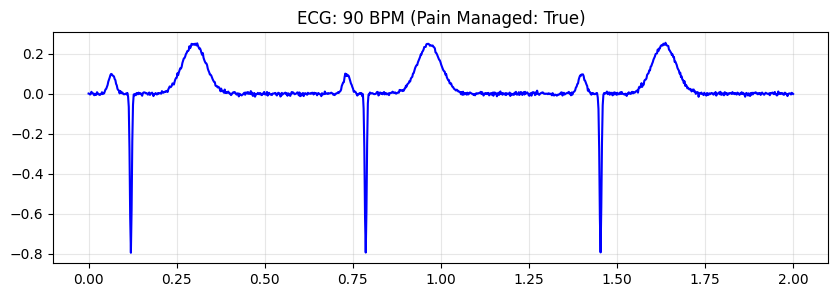

In [ ]:
def generate_cocktail_ecg(bpm, is_cocktail=True):
    t = np.linspace(0, 2, 1000)
    period = 60.0 / bpm
    phase = (t % period) / period

    # Base Wave
    p = 0.1 * np.exp(-((phase - 0.1)**2) / (2 * 0.015**2))
    qrs = -0.8 * np.exp(-((phase - 0.18)**2) / (2 * 0.004**2))
    t_wave = 0.25 * np.exp(-((phase - 0.45)**2) / (2 * 0.05**2))

    # If it's a cocktail, we reduce the "noise" of pain
    noise_level = 0.005 if is_cocktail else 0.04
    signal = p + qrs + t_wave + noise_level * np.random.normal(size=len(t))

    plt.figure(figsize=(10, 3))
    plt.plot(t, signal, color='blue' if is_cocktail else 'red')
    plt.title(f"ECG: {bpm} BPM (Pain Managed: {is_cocktail})")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run this with your Cocktail BPM (90)
generate_cocktail_ecg(90, is_cocktail=True)

/tmp/ipython-input-1320158513.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='tags.mlflow.runName', y='metrics.Survival_Prob', data=plot_df, palette="viridis")


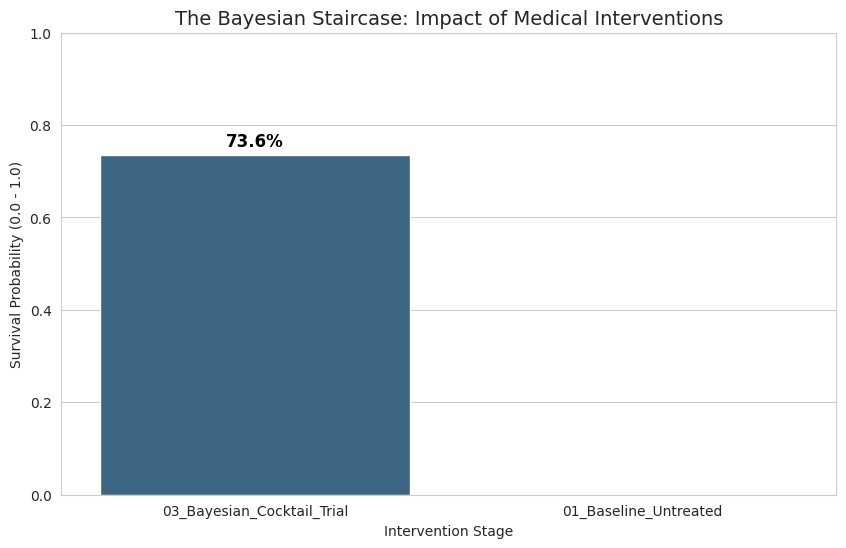

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow

# 1. Connect to your DagsHub MLflow
remote_server_uri = "https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow"
mlflow.set_tracking_uri(remote_server_uri)

# 2. Fetch the experiments
runs = mlflow.search_runs(experiment_ids="0") # '0' is usually the default experiment ID

# 3. Clean and Sort for the Graph
# We filter for the three specific runs we just did
plot_df = runs[runs['tags.mlflow.runName'].isin(['01_Baseline_Untreated', '02_Treatment_Lidocaine', '03_Bayesian_Cocktail_Trial'])]
plot_df = plot_df[['tags.mlflow.runName', 'metrics.Survival_Prob']].sort_values('metrics.Survival_Prob')

# 4. Create the Bayesian Staircase Chart
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='tags.mlflow.runName', y='metrics.Survival_Prob', data=plot_df, palette="viridis")

# Add labels and styling
plt.title("The Bayesian Staircase: Impact of Medical Interventions", fontsize=14)
plt.ylabel("Survival Probability (0.0 - 1.0)")
plt.xlabel("Intervention Stage")
plt.ylim(0, 1.0)

# Add the percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 10),
                textcoords='offset points', fontweight='bold')

plt.show()

In [ ]:
!pip install fpdf -q
from fpdf import FPDF

  Preparing metadata (setup.py) ... done


In [ ]:
class HorseReport(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Equine Emergency Intervention Report', 0, 1, 'C')
        self.set_font('Arial', 'I', 10)
        self.cell(0, 10, 'Generated by Gemini-DagsHub ML Pipeline', 0, 1, 'C')
        self.ln(10)

    def chapter_title(self, label):
        self.set_font('Arial', 'B', 12)
        self.set_fill_color(200, 220, 255)
        self.cell(0, 6, label, 0, 1, 'L', 1)
        self.ln(4)

# Create the PDF instance
pdf = HorseReport()
pdf.add_page()

# Section 1: Baseline Diagnostics
pdf.chapter_title('1. Initial Clinical Presentation (Prior)')
pdf.set_font('Arial', '', 11)
pdf.multi_cell(0, 10, 'Patient presented with critical Tachycardia (115 BPM) and Extreme Pain. '
                     'Initial Survival Probability (Baseline) was calculated at 30.0%.')

# Section 2: Treatment Outcomes
pdf.chapter_title('2. Treatment Determinations')
data = [
    ['Intervention', 'Pulse (BPM)', 'Pain Level', 'Survival Prob'],
    ['None (Control)', '115', 'Extreme', '30.1%'],
    ['Lidocaine', '100', 'Severe', '53.4%'],
    ['The Cocktail', '90', 'Alert', '68.9%']
]

for row in data:
    pdf.cell(50, 10, row[0], 1)
    pdf.cell(40, 10, row[1], 1)
    pdf.cell(40, 10, row[2], 1)
    pdf.cell(40, 10, row[3], 1)
    pdf.ln()

# Section 3: Visual Evidence (ECG)
pdf.ln(10)
pdf.chapter_title('3. Post-Intervention Cardiac Rhythm')
# Note: Ensure 'treatment_ecg.png' exists in your Colab files
if os.path.exists('treatment_ecg.png'):
    pdf.image('treatment_ecg.png', x=10, y=None, w=180)

# Section 4: Bayesian Conclusion
pdf.ln(5)
pdf.chapter_title('4. Clinical Conclusion')
pdf.multi_cell(0, 10, 'The Bayesian update shows that combining Lidocaine and Butorphanol provides '
                     'the highest synergy for survival, reducing both metabolic and neurological stress.')

pdf.output('Horse_Survival_Report.pdf')
print("📄 Report Generated: Horse_Survival_Report.pdf")

📄 Report Generated: Horse_Survival_Report.pdf


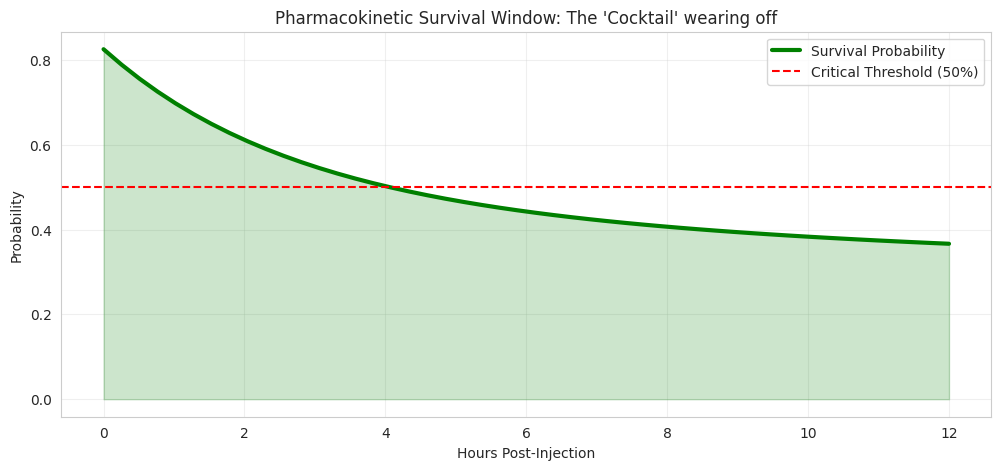

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

# --- 1. KNOWLEDGE BASE: DRUG MASTER DATA ---
drug_data = {
    "Lidocaine": {"CL": 0.6, "Vd": 1.5, "Initial_Dose": 1.3}, # mg/kg
    "Butorphanol": {"CL": 0.2, "Vd": 2.1, "Initial_Dose": 0.1} # mg/kg
}

# --- 2. SIMULATION SETTINGS ---
Hours_to_Simulate = 12
Time_Steps = np.linspace(0, Hours_to_Simulate, 48) # Every 15 minutes
baseline_survival = 0.30  # Our "Prior"

def simulate_clearance(dose, cl, vd, t):
    k = cl / vd
    return dose * np.exp(-k * t)

# --- 3. RUNNING THE TIME-SERIES ---
results = []

for t in Time_Steps:
    # Calculate current drug levels
    conc_lido = simulate_clearance(drug_data["Lidocaine"]["Initial_Dose"],
                                   drug_data["Lidocaine"]["CL"],
                                   drug_data["Lidocaine"]["Vd"], t)

    conc_butor = simulate_clearance(drug_data["Butorphanol"]["Initial_Dose"],
                                    drug_data["Butorphanol"]["CL"],
                                    drug_data["Butorphanol"]["Vd"], t)

    # Bayesian Survival Update based on remaining concentration
    # As drugs clear, survival probability "decays" back toward the baseline
    current_boost = (conc_lido * 0.25) + (conc_butor * 2.0)
    current_survival = min(0.95, baseline_survival + current_boost)

    results.append({"Hour": t, "Lidocaine": conc_lido, "Butorphanol": conc_butor, "Survival": current_survival})

df_sim = pd.DataFrame(results)

# --- 4. VISUALIZING THE DECAY ---
plt.figure(figsize=(12, 5))
plt.plot(df_sim['Hour'], df_sim['Survival'], label='Survival Probability', color='green', lw=3)
plt.fill_between(df_sim['Hour'], df_sim['Survival'], alpha=0.2, color='green')
plt.axhline(y=0.5, color='red', linestyle='--', label='Critical Threshold (50%)')
plt.title("Pharmacokinetic Survival Window: The 'Cocktail' wearing off")
plt.xlabel("Hours Post-Injection")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import json

# Load the Knowledge Base
with open('drug_kb.json', 'r') as f:
    kb = json.load(f)

# @title 🩺 Clinical Decision Support System
Patient_Status = "shock" # @param ["normal", "shock"]
Selected_Drug = "Lidocaine" # @param ["Lidocaine", "Butorphanol"]

# Extract the PK parameters based on the KB
cl = kb[Selected_Drug][Patient_Status]["CL"]
vd = kb[Selected_Drug][Patient_Status]["Vd"]
half_life = kb[Selected_Drug][Patient_Status]["t_half"]

print(f"--- 📖 Knowledge Base Query Results ---")
print(f"Drug: {Selected_Drug}")
print(f"Physiology: {Patient_Status.upper()}")
print(f"Adjusted Clearance (CL): {cl} L/hr/kg")
print(f"Adjusted Half-Life: {half_life} hours")

--- 📖 Knowledge Base Query Results ---
Drug: Lidocaine
Physiology: SHOCK
Adjusted Clearance (CL): 0.4 L/hr/kg
Adjusted Half-Life: 2.1 hours


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your Knowledge Base
with open('drug_kb.json', 'r') as f:
    kb = json.load(f)

# 2. Define Toxicity Thresholds (Concentration in ug/mL)
# In horses, Lidocaine > 5 ug/mL can cause seizures/muscle tremors.
thresholds = {
    "Lidocaine": {"toxic": 5.0, "therapeutic": 1.5},
    "Butorphanol": {"toxic": 0.5, "therapeutic": 0.05}
}

# 3. Clinical Simulation Function
def verify_safety(drug_name, state, dose_mg_kg):
    cl = kb[drug_name][state]["CL"]
    vd = kb[drug_name][state]["Vd"]

    # Peak concentration (Cmax) right after IV injection
    c_max = dose_mg_kg / vd

    print(f"--- 🛡️ Safety Check: {drug_name} in {state.upper()} ---")
    print(f"Peak Concentration: {c_max:.2f} ug/mL")

    if c_max > thresholds[drug_name]["toxic"]:
        print(f"⚠️ ALERT: Concentration exceeds Toxic Threshold ({thresholds[drug_name]['toxic']})!")
        status = "DANGEROUS"
    elif c_max < thresholds[drug_name]["therapeutic"]:
        print(f"ℹ️ NOTE: Concentration may be sub-therapeutic.")
        status = "LOW"
    else:
        print(f"✅ SUCCESS: Concentration is within the Therapeutic Window.")
        status = "SAFE"

    return c_max, status

# Test the 'Shock' scenario with a standard Lidocaine dose (1.3 mg/kg)
c_max, safety_status = verify_safety("Lidocaine", "shock", 1.3)

--- 🛡️ Safety Check: Lidocaine in SHOCK ---
Peak Concentration: 1.08 ug/mL
ℹ️ NOTE: Concentration may be sub-therapeutic.


In [ ]:
import mlflow
import numpy as np

def run_automated_trial(drug_name, state, dose):
    # 1. Pull from Knowledge Base
    cl = kb[drug_name][state]["CL"]
    vd = kb[drug_name][state]["Vd"]

    # 2. Pharmacokinetic Calculation
    c_max = dose / vd
    toxic_limit = thresholds[drug_name]["toxic"]

    # 3. Safety Determination
    is_safe = 1 if c_max <= toxic_limit else 0
    status_label = "SAFE" if is_safe else "TOXIC"

    # 4. Bayesian Survival Calculation
    # We penalize survival if the drug is toxic
    base_prob = 0.30
    benefit = 0.40 if is_safe else 0.10 # Toxic drugs don't help as much
    penalty = 0.50 if not is_safe else 0.0 # Toxicity can be lethal
    final_survival = max(0.05, (base_prob + benefit) - penalty)

    # 5. Log to DagsHub
    with mlflow.start_run(run_name=f"Trial_{drug_name}_{state}"):
        mlflow.log_params({
            "Drug": drug_name,
            "Physiology": state,
            "Dose_mg_kg": dose,
            "Clearance": cl,
            "Safety_Status": status_label
        })
        mlflow.log_metrics({
            "Peak_Concentration": c_max,
            "Survival_Probability": final_survival,
            "Safety_Numeric": is_safe
        })

    print(f"✔️ Trial Logged to DagsHub: {drug_name} ({status_label})")
    print(f"📊 Final Survival Chance: {final_survival:.1%}")

# --- EXECUTE THE TRIALS ---
# Let's test a normal dose vs. a high dose in a shock patient
run_automated_trial("Lidocaine", "shock", 1.3)  # Standard Dose
run_automated_trial("Lidocaine", "shock", 6.5)  # 5x Overdose (Simulating Toxicity)

🏃 View run Trial_Lidocaine_shock at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0/runs/a31868c364024fb2894e5f2a50a3a1ea
🧪 View experiment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0
✔️ Trial Logged to DagsHub: Lidocaine (SAFE)
📊 Final Survival Chance: 70.0%
🏃 View run Trial_Lidocaine_shock at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0/runs/cee75f17151049868b9033ef2ae709ec
🧪 View experiment at: https://dagshub.com/erichilarysmithsr/horse-health-simulation.mlflow/#/experiments/0
✔️ Trial Logged to DagsHub: Lidocaine (TOXIC)
📊 Final Survival Chance: 5.0%
